In [1]:
import pandas as pd # wczytywanie CSV i przeglądanie tabeli
import numpy as np # Operacje na liczbach (średnie, sumy)
import matplotlib.pyplot as plt # Wykresy (słupki, linie, histogramy)
import seaborn as sns # Ładniejsze wykresy statystyczne

print("Wszystko działa!")

Wszystko działa!


In [2]:
df = pd.read_csv("../data/application_train.csv")
print(f'dane wczytane: {df.shape}')
# df.shape - ile wierszy i kolumn ma ta tabela 
# (307511, 122) = 307,511 wierszy, 122 kolumny


dane wczytane: (307511, 122)


In [3]:
df.head()
# zwraca pierwsze 5 wierszy tabeli
# Domyślnie 5, ale możesz dać liczbę w nawiasie, np. df.head(10) żeby zobaczyć 10

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [5]:
description = pd.read_csv("../data/HomeCredit_columns_description.csv", encoding="latin-1")
description.head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [6]:
df.info(verbose=True, show_counts=True)
# verbose=True mówi: pokaż mi każdą kolumnę z osobna, bez skracania.
# show_counts=True wymusza pokazanie „Non-Null Count" (ile wartości niepustych jest w każdej kolumnie).


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

| Klasa pozytywna | Ta którą próbujemy wykryć (u nas: TARGET=1, niespłacający) |
| Niezbalansowane klasy | Gdy jedna klasa jest dużo liczniejsza (u nas 92% vs 8%) |
| Accuracy paradox | Wysokie accuracy może być oszukańcze przy niezbalansowanych klasach |
| TP (True Positive) | Model trafił, że to klasa pozytywna |
| TN (True Negative) | Model trafił, że to klasa negatywna |
| FP (False Positive) | Model błędnie krzyknął "to ta klasa!" |
| FN (False Negative) | Model błędnie powiedział "to nie ta klasa" | GORSZE

Podejście 1: df["TARGET"]:
dostajesz całą kolumnę jako oddzielną „mini-tabelę"

Podejście 2: df.TARGET:
to samo, krótszy zapis (działa, ale tylko jak nazwa nie ma spacji)

Jak już masz kolumnę, to potem dorzucasz na końcu co chcesz z nią zrobić. Na przykład:

.sum() — dodaj wszystkie wartości
.mean() — średnia
.value_counts() — policz, ile razy występuje każda wartość

In [7]:
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

df["TARGET"].value_counts() — zwraca TABELKĘ z dwoma wartościami (0 i 1)

jest 24825 niespłacających'
a 282686 spłacających

In [8]:
df["TARGET"].value_counts()[1] # tylko 1 zlicza

24825

In [9]:
df["TARGET"].value_counts(normalize=True)


TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

mamy procent z tego

0 jest 92%
1 jest 8%

<Axes: xlabel='TARGET', ylabel='count'>

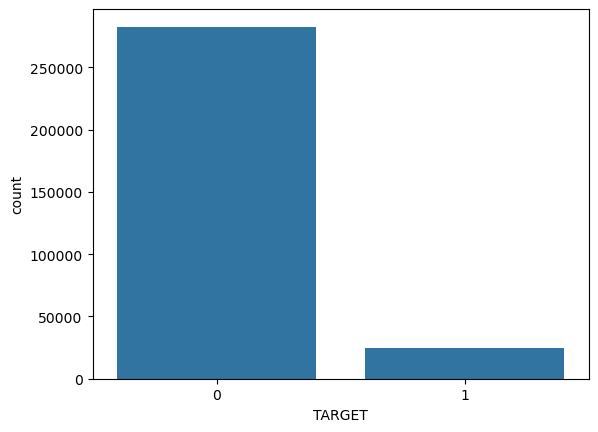

In [10]:
sns.countplot(data = df, x="TARGET")

C:\Users\adamc\AppData\Local\Temp\ipykernel_13152\1426130671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="TARGET", palette=["#2ecc71", "#e74c3c"])


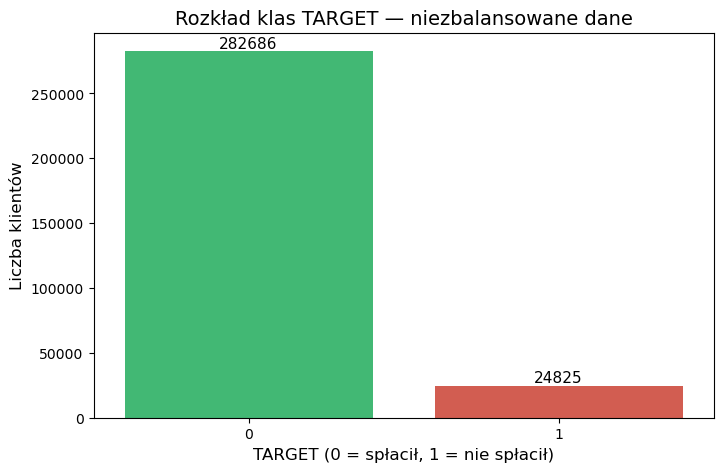

In [11]:
# Tworzymy wykres
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="TARGET", palette=["#2ecc71", "#e74c3c"])

# Tytuł i etykiety
plt.title("Rozkład klas TARGET — niezbalansowane dane", fontsize=14)
plt.xlabel("TARGET (0 = spłacił, 1 = nie spłacił)", fontsize=12)
plt.ylabel("Liczba klientów", fontsize=12)

# Dodajemy liczby na słupkach
for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.show()




In [12]:
df.shape

(307511, 122)

In [13]:
df.isna().sum().sort_values(ascending=False).head(10)

COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MEDI    213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
dtype: int64

In [14]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False).head(10)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
dtype: float64

In [15]:
procenty = df.isna().sum() / len(df) * 100
(procenty > 50).sum()

41

## Decyzja: kolumny z >50% braków usuwamy

Polityka projektu: kolumny, które mają więcej niż 50% braków danych, 
zostaną usunięte przed treningiem modelu.

**Uzasadnienie:** Uzupełnianie tylu wartości wprowadziłoby dużo sztucznych danych.
Model uczyłby się szumu zamiast prawdziwych zależności.

Łącznie do usunięcia: **41 kolumn** (33% wszystkich).

In [16]:
kolumny_do_usuniecia = procenty[procenty > 50].index.tolist()
print(f"Liczba kolumn do usunięcia: {len(kolumny_do_usuniecia)}")
print(f"kolumny: {kolumny_do_usuniecia[:]}")

Liczba kolumn do usunięcia: 41
kolumny: ['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE']


In [17]:
df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].isna().sum()

EXT_SOURCE_1    173378
EXT_SOURCE_2       660
EXT_SOURCE_3     60965
dtype: int64

Jedyną podejrzaną kolumną na liście do usunięcia była **EXT_SOURCE_1** 
(zewnętrzny scoring kredytowy - silny predyktor spłaty).
Ale EXT_SOURCE_2 i EXT_SOURCE_3 są prawie kompletne i niosą 
podobną informację. Strata EXT_SOURCE_1 jest akceptowalna.

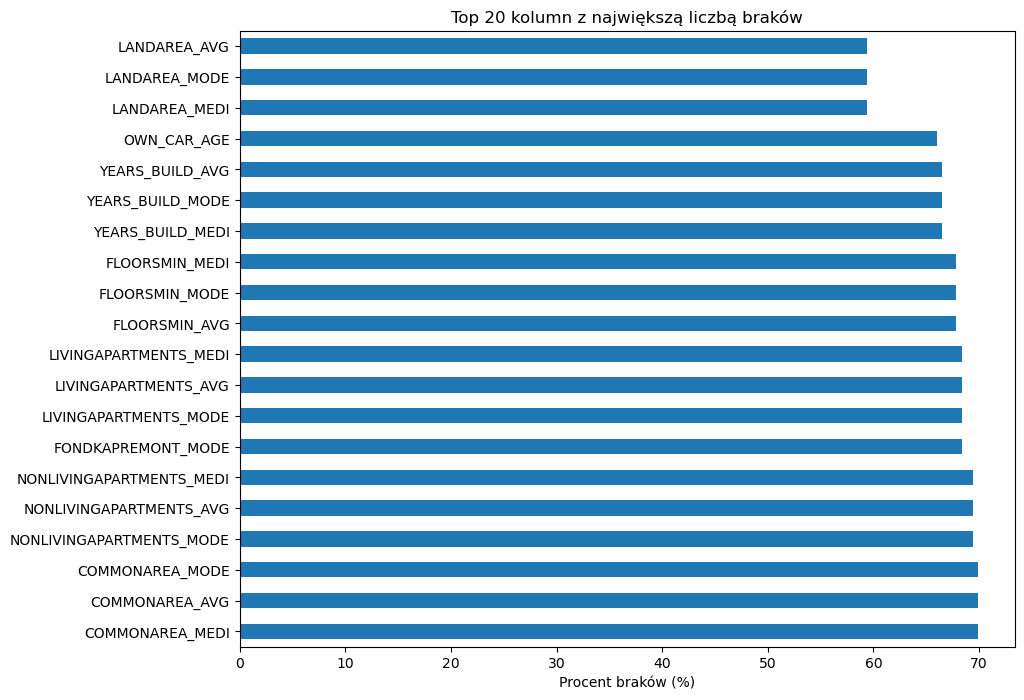

In [18]:
procenty.sort_values(ascending=False).head(20).plot(kind="barh", figsize=(10, 8))
plt.title("Top 20 kolumn z największą liczbą braków")
plt.xlabel("Procent braków (%)")
plt.show()

In [19]:
df_clean = df.drop(columns=kolumny_do_usuniecia)
print(f"Przed: {df.shape}")
print(f"Po: {df_clean.shape}")

Przed: (307511, 122)
Po: (307511, 81)


In [20]:
y = df_clean["TARGET"]
X = df_clean.drop(columns=["TARGET"])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (307511, 80)
y shape: (307511,)


In [21]:
kolumny_numeryczne = X.select_dtypes(include="number").columns.tolist()
kolumny_kategoryczne = X.select_dtypes(include="object").columns.tolist()

print(f"Liczbowe: {len(kolumny_numeryczne)} kolumn")
print(f"Kategoryczne: {len(kolumny_kategoryczne)} kolumn")
print(f"\nPrzykłady kategorycznych: {kolumny_kategoryczne[:5]}")

Liczbowe: 67 kolumn
Kategoryczne: 13 kolumn

Przykłady kategorycznych: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE']


In [22]:
# Kolumny liczbowe - mediana
for col in kolumny_numeryczne:
    X[col] = X[col].fillna(X[col].median())

# Kolumny kategoryczne - "missing"
for col in kolumny_kategoryczne:
    X[col] = X[col].fillna("missing")

print(f"Braki po uzupełnieniu: {X.isna().sum().sum()}")

Braki po uzupełnieniu: 0


In [23]:
X = pd.get_dummies(X, columns=kolumny_kategoryczne, drop_first=True)
print(f"Nowy shape X: {X.shape}")
print(f"Wszystkie kolumny liczbowe? {X.dtypes.unique()}")

Nowy shape X: (307511, 183)
Wszystkie kolumny liczbowe? [dtype('int64') dtype('float64') dtype('bool')]


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape: {X_scaled.shape}")
print(f"Pierwsze 5 wartości pierwszej kolumny: {X_scaled[:5, 0]}")

Shape: (307511, 183)
Pierwsze 5 wartości pierwszej kolumny: [-1.73342255 -1.73341283 -1.7334031  -1.73338364 -1.73337391]


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"\nProporcja klas w train: {y_train.mean():.4f}")
print(f"Proporcja klas w val: {y_val.mean():.4f}")

X_train: (246008, 183), y_train: (246008,)
X_val: (61503, 183), y_val: (61503,)

Proporcja klas w train: 0.0807
Proporcja klas w val: 0.0807


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# Tworzymy i trenujemy model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predykcje na zbiorze walidacyjnym
y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]  # prawdopodobieństwa klasy 1

# Metryki
auc = roc_auc_score(y_val, y_proba)
print(f"ROC-AUC: {auc:.4f}")
print(f"\nClassification report:")
print(classification_report(y_val, y_pred))

ROC-AUC: 0.7451

Classification report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.54      0.01      0.02      4965

    accuracy                           0.92     61503
   macro avg       0.73      0.51      0.49     61503
weighted avg       0.89      0.92      0.88     61503



In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Ziarno losowości — żeby wyniki były powtarzalne
tf.random.set_seed(42)

# Budujemy sieć
model_nn1 = keras.Sequential([
    layers.Input(shape=(183,)),       # warstwa wejściowa: 183 cechy
    layers.Dense(64, activation="relu"),  # ukryta 1: 64 neurony + ReLU
    layers.Dense(32, activation="relu"),  # ukryta 2: 32 neurony + ReLU
    layers.Dense(1, activation="sigmoid") # wyjście: 1 neuron + sigmoid
])

# Pokazujemy strukturę
model_nn1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        11,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,889 (54.25 KB)

 Trainable params: 13,889 (54.25 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Kompilacja sieci
model_nn1.compile(
    optimizer="adam",                  # najpopularniejszy optimizer
    loss="binary_crossentropy",        # standardowa strata dla klasyfikacji 2 klas
    metrics=["AUC"]                    # śledzimy AUC podczas treningu
)

# Liczymy wagi klas (bo niezbalansowane: 92% vs 8%)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Wagi klas: {class_weight_dict}")

# Trening!
history_nn1 = model_nn1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=256,
    class_weight=class_weight_dict,
    verbose=1
)

Wagi klas: {0: 0.5439092983356032, 1: 6.193554884189325}
Epoch 1/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.7144 - loss: 0.6228 - val_AUC: 0.7364 - val_loss: 0.5902
Epoch 2/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.7426 - loss: 0.5983 - val_AUC: 0.7379 - val_loss: 0.5816
Epoch 3/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - AUC: 0.7499 - loss: 0.5918 - val_AUC: 0.7370 - val_loss: 0.5817
Epoch 4/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.7555 - loss: 0.5866 - val_AUC: 0.7361 - val_loss: 0.5833
Epoch 5/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.7609 - loss: 0.5814 - val_AUC: 0.7347 - val_loss: 0.5800
Epoch 6/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.7662 - loss: 0.5762 - val_AUC: 0.7327 - val_loss: 0.5833
Epoch 7/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.7711 - loss: 0.5713 - val_AUC: 0.7312 - val_loss: 0.5834
Epoch 8/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.7758 - loss: 0.5664 - val_AUC: 0.7284 - val_loss: 0.5813

In [29]:
from sklearn.metrics import roc_auc_score, classification_report

# Predykcje sieci na walidacji
y_proba_nn1 = model_nn1.predict(X_val, verbose=0).flatten()
y_pred_nn1 = (y_proba_nn1 > 0.5).astype(int)

# Metryki
auc_nn1 = roc_auc_score(y_val, y_proba_nn1)
print(f"ROC-AUC sieć MLP nr 1: {auc_nn1:.4f}")
print(f"ROC-AUC baseline (regresja): 0.7451")
print(f"\nClassification report sieci:")
print(classification_report(y_val, y_pred_nn1))

ROC-AUC sieć MLP nr 1: 0.7240
ROC-AUC baseline (regresja): 0.7451

Classification report sieci:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.15      0.65      0.25      4965

    accuracy                           0.68     61503
   macro avg       0.56      0.67      0.52     61503
weighted avg       0.89      0.68      0.75     61503



In [30]:
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

# Sieć nr 2: większa + Dropout
model_nn2 = keras.Sequential([
    layers.Input(shape=(183,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),                    # wyłącz 30% neuronów losowo
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model_nn2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC"]
)

# Early stopping — przestań trenować jak val_AUC nie rośnie przez 3 epoki
early_stop = EarlyStopping(
    monitor="val_AUC",
    mode="max",                # AUC chcemy MAKSYMALNE
    patience=3,                # poczekaj 3 epoki bez poprawy
    restore_best_weights=True  # przywróć wagi z najlepszej epoki
)

history_nn2 = model_nn2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,                 # max 30 (early stopping i tak przerwie)
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("\n--- Trening zakończony ---")

Epoch 1/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.6888 - loss: 0.6414 - val_AUC: 0.7388 - val_loss: 0.5905
Epoch 2/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.7285 - loss: 0.6126 - val_AUC: 0.7398 - val_loss: 0.5716
Epoch 3/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.7346 - loss: 0.6069 - val_AUC: 0.7413 - val_loss: 0.5789
Epoch 4/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.7380 - loss: 0.6034 - val_AUC: 0.7416 - val_loss: 0.5733
Epoch 5/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.7403 - loss: 0.6013 - val_AUC: 0.7414 - val_loss: 0.5803
Epoch 6/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.7425 - loss: 0.5998 - val_AUC: 0.7414 - val_loss: 0.5796
Epoch 7/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.7444 - loss: 0.5973 - val_AUC: 0.7426 - val_loss: 0.5735
Epoch 8/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.7462 - loss: 0.5957 - val_AUC: 0.7426 - val_loss: 0.5650
Epoch 9/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AU

In [31]:
# Predykcje sieci 2
y_proba_nn2 = model_nn2.predict(X_val, verbose=0).flatten()
y_pred_nn2 = (y_proba_nn2 > 0.5).astype(int)

auc_nn2 = roc_auc_score(y_val, y_proba_nn2)

print(f"Porównanie modeli (val AUC):")
print(f"  1. Baseline (regresja):      0.7451")
print(f"  2. Sieć MLP nr 1 (bez reg.): 0.7240")
print(f"  3. Sieć MLP nr 2 (Dropout):  {auc_nn2:.4f}")
print(f"\nClassification report sieci nr 2:")
print(classification_report(y_val, y_pred_nn2))

Porównanie modeli (val AUC):
  1. Baseline (regresja):      0.7451
  2. Sieć MLP nr 1 (bez reg.): 0.7240
  3. Sieć MLP nr 2 (Dropout):  0.7432

Classification report sieci nr 2:
              precision    recall  f1-score   support

           0       0.96      0.67      0.79     56538
           1       0.16      0.70      0.25      4965

    accuracy                           0.67     61503
   macro avg       0.56      0.68      0.52     61503
weighted avg       0.90      0.67      0.74     61503



In [32]:
from tensorflow.keras.regularizers import l2

tf.random.set_seed(42)

# Sieć 3: głębsza + L2 + lekki Dropout
model_nn3 = keras.Sequential([
    layers.Input(shape=(183,)),
    layers.Dense(256, activation="relu", kernel_regularizer=l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_nn3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),  # mniejszy LR
    loss="binary_crossentropy",
    metrics=["AUC"]
)

early_stop = EarlyStopping(
    monitor="val_AUC",
    mode="max",
    patience=5,
    restore_best_weights=True
)

history_nn3 = model_nn3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("\n--- Trening zakończony ---")

Epoch 1/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - AUC: 0.6843 - loss: 0.9407 - val_AUC: 0.7390 - val_loss: 0.7596
Epoch 2/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.7285 - loss: 0.7415 - val_AUC: 0.7411 - val_loss: 0.6554
Epoch 3/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - AUC: 0.7346 - loss: 0.6637 - val_AUC: 0.7413 - val_loss: 0.6091
Epoch 4/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.7363 - loss: 0.6345 - val_AUC: 0.7410 - val_loss: 0.6000
Epoch 5/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - AUC: 0.7360 - loss: 0.6253 - val_AUC: 0.7417 - val_loss: 0.5933
Epoch 6/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.7374 - loss: 0.6209 - val_AUC: 0.7413 - val_loss: 0.5873
Epoch 7/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - AUC: 0.7375 - loss: 0.6195 - val_AUC: 0.7418 - val_loss: 0.5941
Epoch 8/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - AUC: 0.7386 - loss: 0.6187 - val_AUC: 0.7416 - val_loss: 0.5889
Epoch 9/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - AU

In [33]:
# Predykcje sieci 3
y_proba_nn3 = model_nn3.predict(X_val, verbose=0).flatten()
y_pred_nn3 = (y_proba_nn3 > 0.5).astype(int)

auc_nn3 = roc_auc_score(y_val, y_proba_nn3)

print(f"=== PORÓWNANIE WSZYSTKICH 4 MODELI ===\n")
print(f"1. Baseline (regresja logistyczna):  AUC = 0.7451")
print(f"2. Sieć MLP nr 1 (bez regularyzacji): AUC = 0.7240")
print(f"3. Sieć MLP nr 2 (Dropout):           AUC = 0.7432")
print(f"4. Sieć MLP nr 3 (L2 + Dropout):      AUC = {auc_nn3:.4f}")

print(f"\nClassification report sieci nr 3:")
print(classification_report(y_val, y_pred_nn3))

=== PORÓWNANIE WSZYSTKICH 4 MODELI ===

1. Baseline (regresja logistyczna):  AUC = 0.7451
2. Sieć MLP nr 1 (bez regularyzacji): AUC = 0.7240
3. Sieć MLP nr 2 (Dropout):           AUC = 0.7432
4. Sieć MLP nr 3 (L2 + Dropout):      AUC = 0.7422

Classification report sieci nr 3:
              precision    recall  f1-score   support

           0       0.96      0.65      0.78     56538
           1       0.15      0.70      0.25      4965

    accuracy                           0.66     61503
   macro avg       0.56      0.68      0.51     61503
weighted avg       0.90      0.66      0.74     61503



## Wyniki — porównanie 4 modeli

| # | Model | Val AUC | Recall klasy 1 | Precision klasy 1 | Accuracy |
|---|---|---|---|---|---|
| 1 | Regresja logistyczna (baseline) | **0.7451** | 0.01 | 0.54 | 0.92 |
| 2 | MLP nr 1 (64-32, brak regularyzacji) | 0.7240 | 0.65 | 0.15 | 0.68 |
| 3 | MLP nr 2 (128-64-32 + Dropout) | 0.7432 | **0.70** | 0.16 | 0.67 |
| 4 | MLP nr 3 (256-128-64-32 + L2 + Dropout) | 0.7422 | 0.70 | 0.15 | 0.66 |

### Wnioski

1. **Regresja logistyczna ma najlepszy AUC** (0.7451), ale **recall klasy 1 = 0.01** — model nie wykrywa niespłacających. Powód: niezbalansowane klasy (92% vs 8%).

2. **Sieć MLP nr 1 (bez regularyzacji)** — klasyczny overfitting:
   - Train AUC rośnie do 0.78
   - Val AUC spada od 0.74 do 0.72
   - Diagnoza: sieć zapamiętuje dane treningowe zamiast uczyć się wzorca

3. **Sieć MLP nr 2 (Dropout)** — regularyzacja skuteczna:
   - Train AUC i Val AUC idą razem (~0.74)
   - Najlepszy recall klasy 1 (0.70)
   - EarlyStopping przerwał trening po epoce 13

4. **Sieć MLP nr 3 (L2 + Dropout)** — głębsza architektura:
   - Najbardziej stabilna (różnica train/val minimalna)
   - Bardzo podobne wyniki jak MLP nr 2

5. **Class weight balanced** drastycznie poprawia recall klasy 1 (z 0.01 do 0.70) — kluczowe dla niezbalansowanych danych w problemach kredytowych, gdzie False Negatives (przepuszczony niespłacający) są kosztowniejsze niż False Positives (odrzucony spłacający).

6. **Sieci neuronowe nie pobiły regresji logistycznej na AUC** — zgodne z literaturą: dla danych tabularnych klasyczne metody (regresja, gradient boosting) są często konkurencyjne lub lepsze od głębokich sieci.

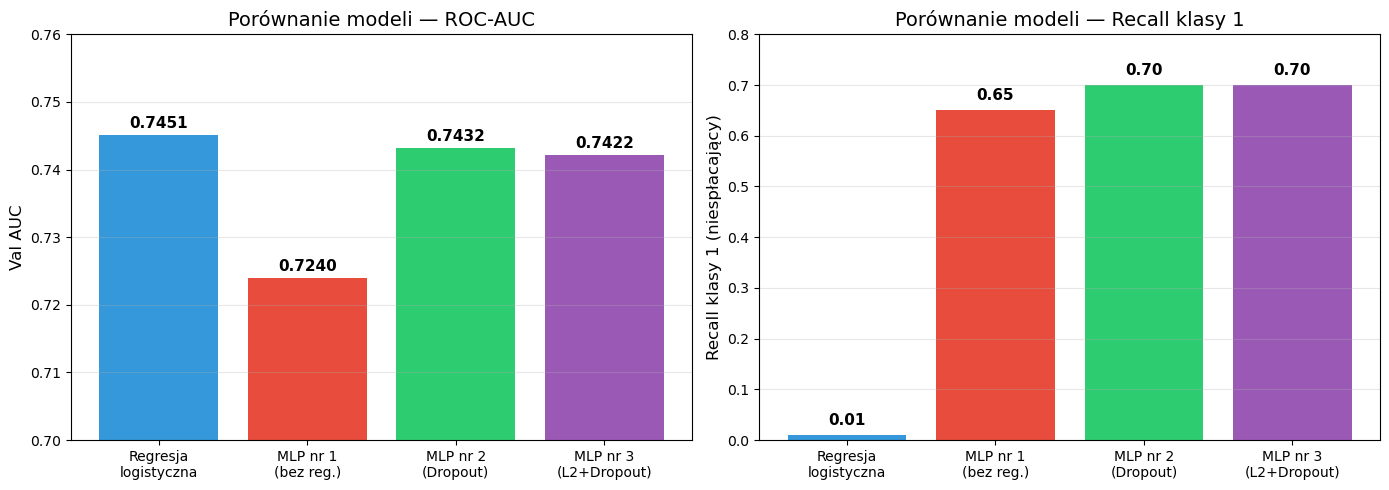

In [34]:
import matplotlib.pyplot as plt

# Dane do wykresu
models = ["Regresja\nlogistyczna", "MLP nr 1\n(bez reg.)", "MLP nr 2\n(Dropout)", "MLP nr 3\n(L2+Dropout)"]
auc_values = [0.7451, 0.7240, 0.7432, 0.7422]
recall_values = [0.01, 0.65, 0.70, 0.70]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres AUC
bars1 = axes[0].bar(models, auc_values, color=["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"])
axes[0].set_ylabel("Val AUC", fontsize=12)
axes[0].set_title("Porównanie modeli — ROC-AUC", fontsize=14)
axes[0].set_ylim(0.70, 0.76)
axes[0].grid(axis="y", alpha=0.3)
for bar, val in zip(bars1, auc_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")

# Wykres Recall klasy 1
bars2 = axes[1].bar(models, recall_values, color=["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"])
axes[1].set_ylabel("Recall klasy 1 (niespłacający)", fontsize=12)
axes[1].set_title("Porównanie modeli — Recall klasy 1", fontsize=14)
axes[1].set_ylim(0, 0.8)
axes[1].grid(axis="y", alpha=0.3)
for bar, val in zip(bars2, recall_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.2f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

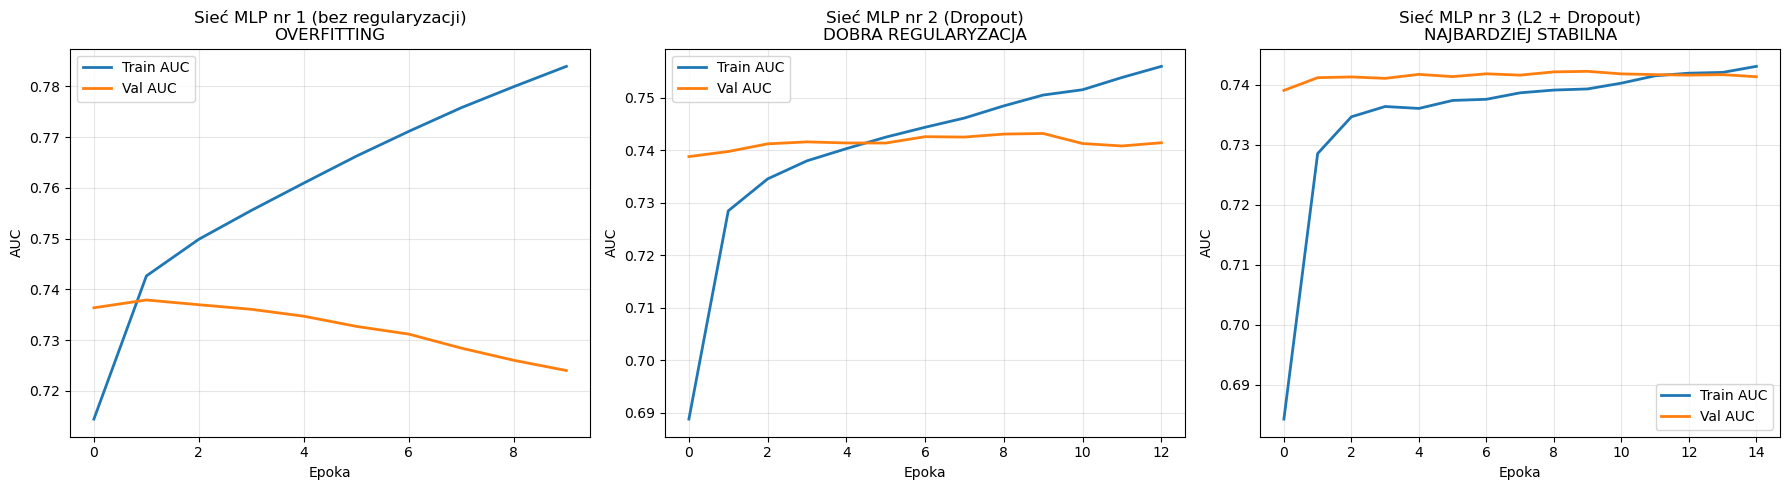

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sieć 1
axes[0].plot(history_nn1.history["AUC"], label="Train AUC", linewidth=2)
axes[0].plot(history_nn1.history["val_AUC"], label="Val AUC", linewidth=2)
axes[0].set_title("Sieć MLP nr 1 (bez regularyzacji)\nOVERFITTING", fontsize=12)
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("AUC")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Sieć 2
axes[1].plot(history_nn2.history["AUC"], label="Train AUC", linewidth=2)
axes[1].plot(history_nn2.history["val_AUC"], label="Val AUC", linewidth=2)
axes[1].set_title("Sieć MLP nr 2 (Dropout)\nDOBRA REGULARYZACJA", fontsize=12)
axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("AUC")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Sieć 3
axes[2].plot(history_nn3.history["AUC"], label="Train AUC", linewidth=2)
axes[2].plot(history_nn3.history["val_AUC"], label="Val AUC", linewidth=2)
axes[2].set_title("Sieć MLP nr 3 (L2 + Dropout)\nNAJBARDZIEJ STABILNA", fontsize=12)
axes[2].set_xlabel("Epoka")
axes[2].set_ylabel("AUC")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()